# W22

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix

In [31]:
# Carica il dataset
data=pd.read_csv('higgs.csv')
data

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,4.505083,b
249996,349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,2.497259,b
249997,349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,...,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.018636,s
249998,349998,94.951,19.362,68.812,13.504,-999.00,-999.000,-999.000,3.365,13.504,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,1.681611,b


In [32]:
X = data.drop(['EventId', 'Label', 'Weight'], axis=1)
X = X.replace(-999.0, np.nan)
X = X.fillna(X.mean())
y = (data['Label'] == 's').astype(int) #labels: 1=segnal 0=background

In [33]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

#Split
X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.33, random_state=42)

AUC: 0.9063


Text(0, 0.5, 'True Positive Rate')

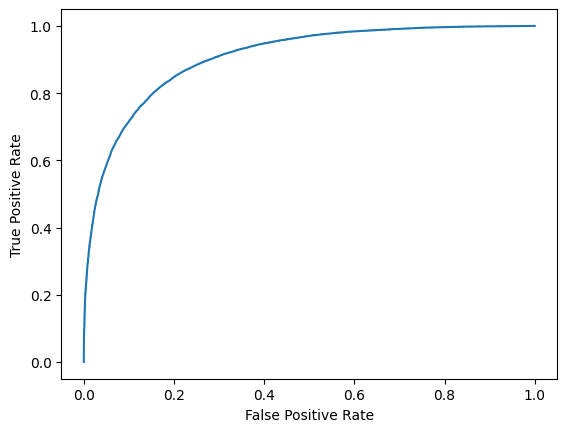

In [34]:
clf = MLPClassifier(
    hidden_layer_sizes=(50,),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

clf.fit(X_train, y_train)  
y_prob = clf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
print(f'AUC: {roc_auc_score(y_test, y_prob):.4f}')


plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

In [37]:
param_grid = {
    'hidden_layer_sizes': [(20,), (50,), (50, 50), (100,)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001],
    'learning_rate_init': [0.001, 0.01]
}

grid = GridSearchCV(
    MLPClassifier(max_iter=1000, random_state=42),
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2,
)

grid.fit(X_train, y_train)  

print("Best parameters:")
print(grid.best_params_)

bestclf = grid.best_estimator_


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best parameters:
{'activation': 'tanh', 'alpha': 0.001, 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}


              precision    recall  f1-score   support

           0       0.87      0.89      0.88     54446
           1       0.78      0.73      0.75     28054

    accuracy                           0.84     82500
   macro avg       0.82      0.81      0.82     82500
weighted avg       0.84      0.84      0.84     82500

Final AUC: 0.9070


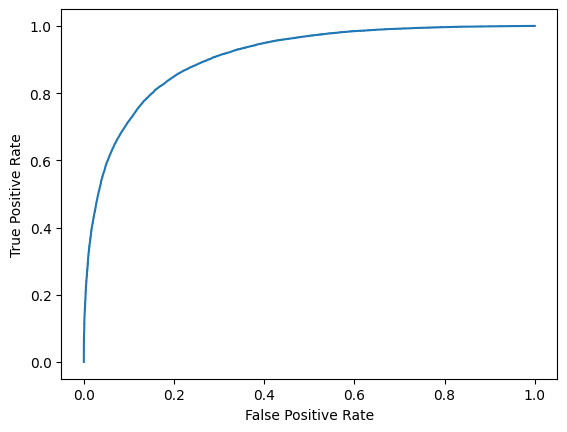

In [38]:
bestclf.fit(X_train, y_train) 

y_pred = bestclf.predict(X_test)
y_prob = bestclf.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

print(f"Final AUC: {roc_auc_score(y_test, y_prob):.4f}")

In [39]:
cm = confusion_matrix(y_test, y_pred)

In [40]:
cm

array([[48597,  5849],
       [ 7563, 20491]])